# Logistic Regression Classification Model

## Project Objective
The objective of this project is to build a machine learning classification
model using Logistic Regression to predict outcomes based on structured
dataset features.

The project demonstrates a complete machine learning workflow including
data preprocessing, exploratory data analysis, model training, and
performance evaluation.

## Technologies
- Python
- Pandas
- NumPy
- Scikit-Learn
- Matplotlib
- Seaborn

# About dataset

This dataset, known as the Framingham Heart Study dataset, is designed for predicting the 10-year risk of future coronary heart disease (CHD) in patients. It contains 4,240 records and 15 attributes, making it a valuable resource for developing predictive models in cardiovascular health research Each attribute is a potential risk factor. There are both demographic, behavioral and medical risk factors.


Demographic:

Sex: male or female(Nominal)

Age: Age of the patient;(Continuous - Although the recorded ages have been truncated to whole numbers, the concept of age is continuous)
Behavioral

 Current Smoker: whether or not the patient is a current smoker (Nominal)

 Cigs Per Day: the number of cigarettes that the person smoked on average in one day.(can be considered continuous as one can have any number of cigarettes, even half a cigarette.)
Medical( history)

 BP Meds: whether or not the patient was on blood pressure medication (Nominal)

 Prevalent Stroke: whether or not the patient had previously had a stroke (Nominal)

 Prevalent Hyp: whether or not the patient was hypertensive (Nominal)

 Diabetes: whether or not the patient had diabetes (Nominal)
Medical(current)

 Tot Chol: total cholesterol level (Continuous)

 Sys BP: systolic blood pressure (Continuous)

 Dia BP: diastolic blood pressure (Continuous)

 BMI: Body Mass Index (Continuous)

 Heart Rate: heart rate (Continuous - In medical research, variables such as heart rate though in fact discrete, yet are considered continuous because of large number of possible values.)

 Glucose: glucose level (Continuous)
Predict variable (desired target)

 10 year risk of coronary heart disease CHD (binary: “1”, means “Yes”, “0” means “No”)

dataset :https://kaggle.com/datasets/dileep070/heart-disease-prediction-using-logistic-regression 

# Prediction Goal: 

The classification goal is to predict whether the patient has 10-year risk of future coronary heart disease (CHD).

# Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold, cross_val_score

# Reading Dataset

In [2]:
df=pd.read_csv(r"C:\Users\asrar\Downloads\heart disease dataset\framingham.csv")



In [3]:
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


# Descriptive Statistics

In [4]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


# Eda Process

In [5]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [6]:
columns=['education','cigsPerDay','BPMeds','totChol','BMI','glucose','heartRate']
for i in columns:
    df[i]=df[i].fillna(df[i].mean())


In [7]:
df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [8]:
print(df['education'].unique())


[4.         2.         1.         3.         1.97894992]


In [9]:
df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [10]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

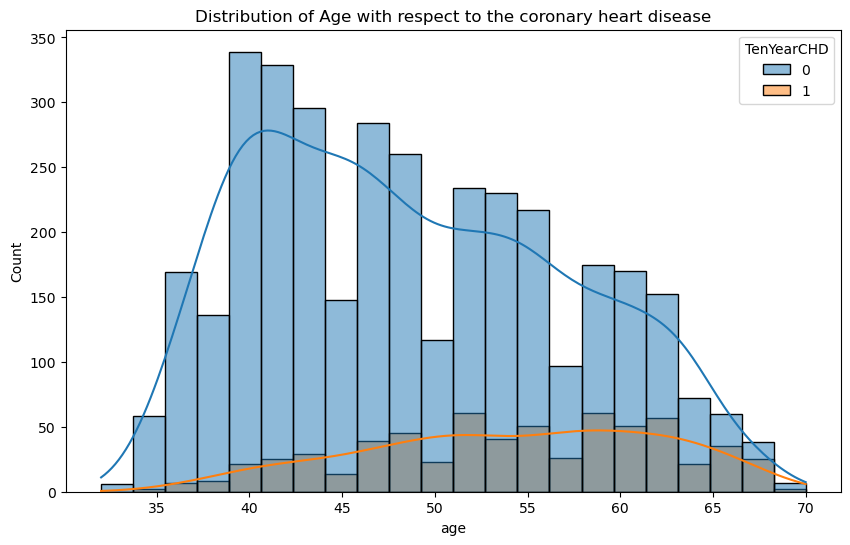

In [11]:
# Visualize the distribution of prices
plt.figure(figsize=(10, 6))
sns.histplot(x=df['age'],hue=df['TenYearCHD'],kde=True)
plt.title('Distribution of Age with respect to the coronary heart disease')
plt.show()

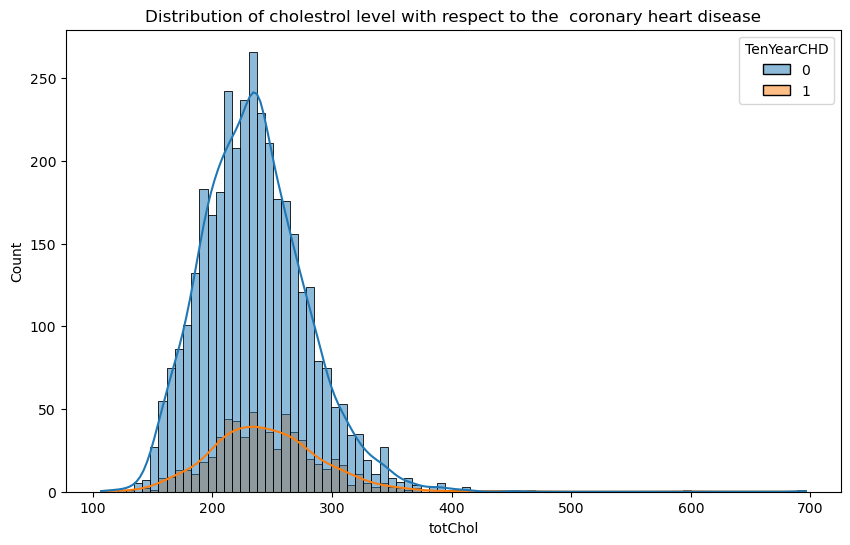

In [12]:
# Visualize the distribution of prices
plt.figure(figsize=(10, 6))
sns.histplot(x=df['totChol'],hue=df['TenYearCHD'],kde=True)
plt.title('Distribution of cholestrol level with respect to the  coronary heart disease')
plt.show()

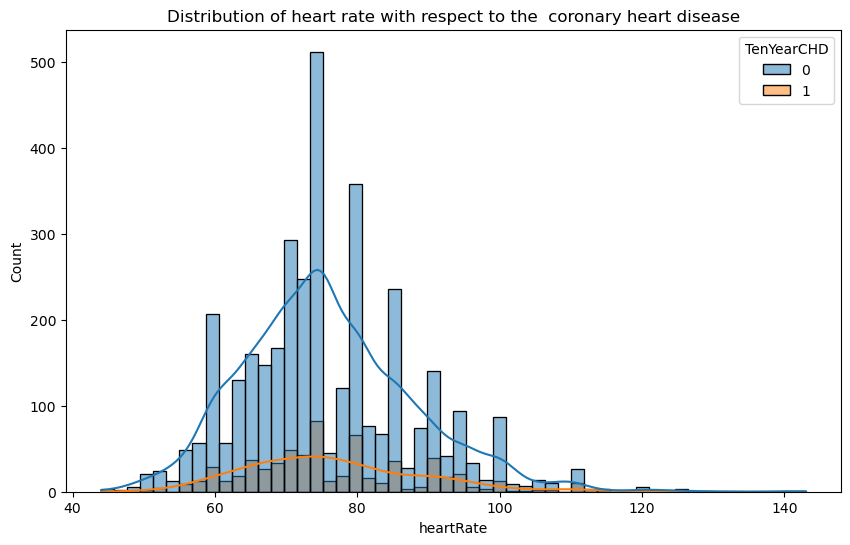

In [13]:
# Visualize the distribution of prices
plt.figure(figsize=(10, 6))
sns.histplot(x=df['heartRate'],hue=df['TenYearCHD'],kde=True)
plt.title('Distribution of heart rate with respect to the  coronary heart disease')
plt.show()

# Feature Engineering

In [14]:
df.columns=df.columns.str.lower()

In [15]:
df

,male,age,education,currentsmoker,cigsperday,bpmeds,prevalentstroke,prevalenthyp,diabetes,totchol,sysbp,diabp,bmi,heartrate,glucose,tenyearchd
0,1,39,4.0,0,0.0,0.00000,0,0,0,195.0,106.0,70.0,26.97,80.0,77.000000,0
1,0,46,2.0,0,0.0,0.00000,0,0,0,250.0,121.0,81.0,28.73,95.0,76.000000,0
2,1,48,1.0,1,20.0,0.00000,0,0,0,245.0,127.5,80.0,25.34,75.0,70.000000,0
3,0,61,3.0,1,30.0,0.00000,0,1,0,225.0,150.0,95.0,28.58,65.0,103.000000,1
4,0,46,3.0,1,23.0,0.00000,0,0,0,285.0,130.0,84.0,23.10,85.0,85.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.00000,0,1,0,313.0,179.0,92.0,25.97,66.0,86.000000,1
4234,1,51,3.0,1,43.0,0.00000,0,0,0,207.0,126.5,80.0,19.71,65.0,68.000000,0
4235,0,48,2.0,1,20.0,0.02963,0,0,0,248.0,131.0,72.0,22.00,84.0,86.000000,0
4236,0,44,1.0,1,15.0,0.00000,0,0,0,210.0,126.5,87.0,19.16,86.0,81.966753,0


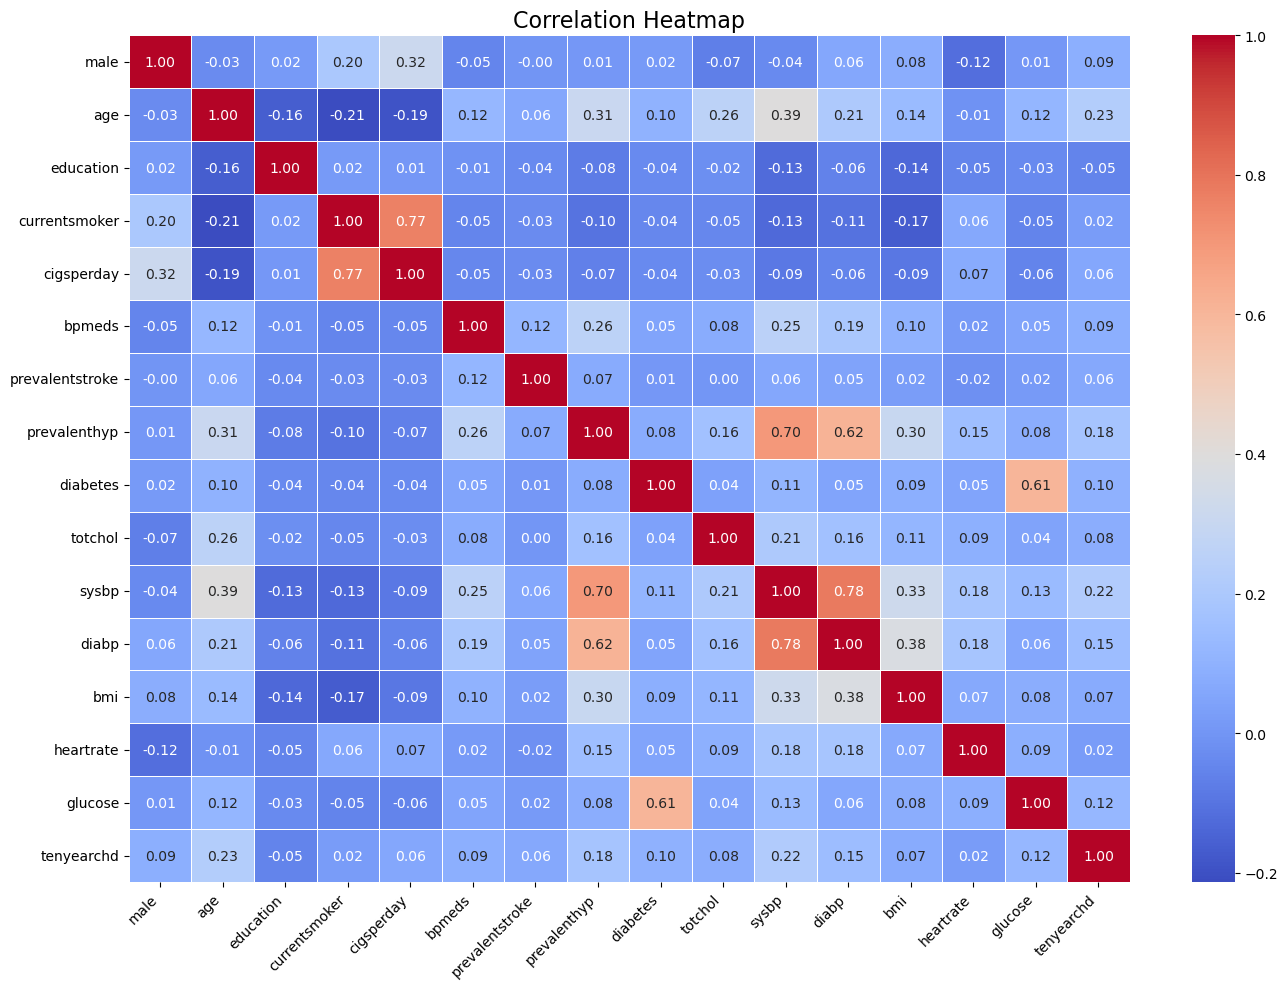

In [16]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

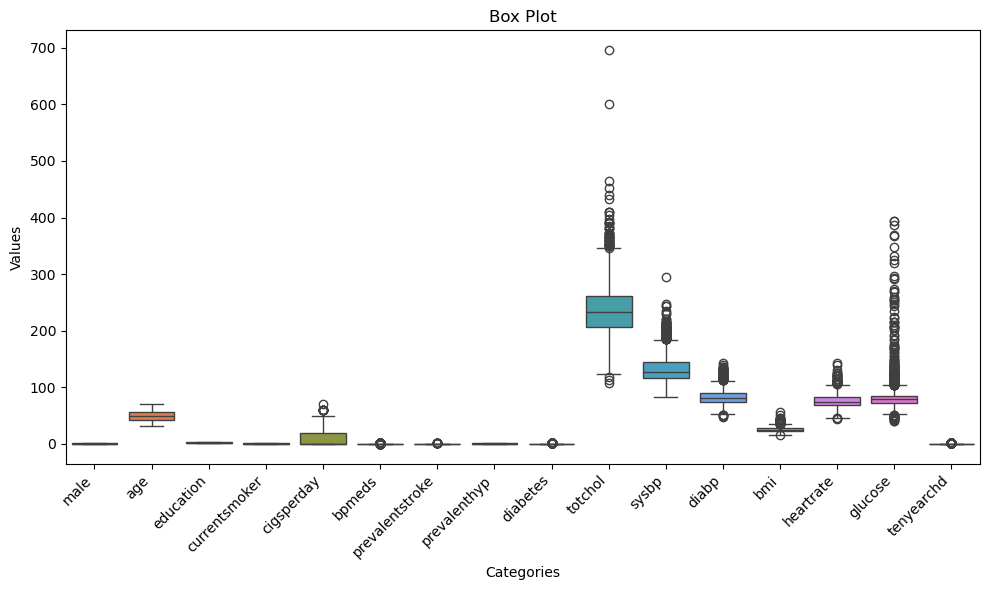

In [17]:

plt.figure(figsize=(10, 6))
sns.boxplot(df)

# Adjust x-axis labels
plt.xticks(rotation=45, ha='right')  # Rotate labels to 45 degrees
plt.xlabel('Categories')
plt.ylabel('Values')
plt.title('Box Plot')

plt.tight_layout()  # Adjust layout to make room for rotated labels
plt.show()

In [18]:
# # Remove outliers
# Q1 = df.quantile(0.25)
# Q3 = df.quantile(0.75)
# IQR = Q3 - Q1

# # Define a filter to remove outliers
# filter = (df >= (Q1 - 3 * IQR)) & (df <= (Q3 + 3 * IQR))

# # Apply the filter and drop rows with any outliers
# df = df[filter.all(axis=1)]

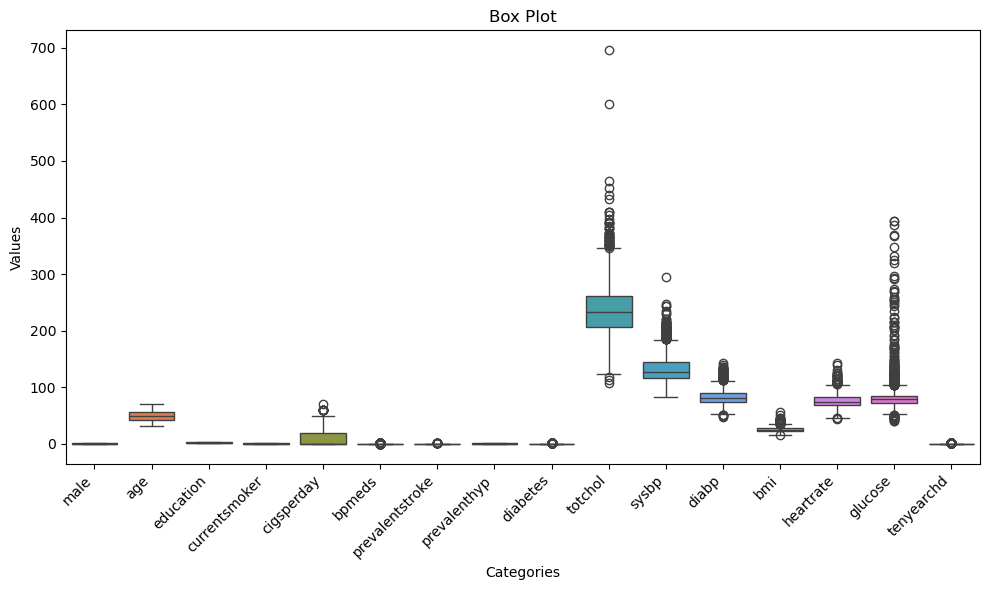

In [19]:

plt.figure(figsize=(10, 6))
sns.boxplot(df)

# Adjust x-axis labels
plt.xticks(rotation=45, ha='right')  # Rotate labels to 45 degrees
plt.xlabel('Categories')
plt.ylabel('Values')
plt.title('Box Plot')

plt.tight_layout()  # Adjust layout to make room for rotated labels
plt.show()

# Splitting Dataset

In [20]:
# X=df.drop(df['tenyearchd'])
# y=df['tenyearchd'] 
features = ['age', 'totchol', 'sysbp', 'diabp', 'bmi', 'heartrate', 'glucose']

y=df['tenyearchd']
X=df[features]

# Model Training

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
lr=LogisticRegression(class_weight='balanced')
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
accuracy_score=accuracy_score(y_test,y_pred)
print(f"Accuracy Score  : {accuracy_score}")

Accuracy Score  : 0.6470125786163522


In [22]:
    params={
        'C': [0.001, 0.01, 0.1, 1, 10,2,5],
        'penalty': ['l2'],
        'max_iter': [200, 500, 1000],
        'solver': ['lbfgs']
    }
scores = cross_val_score(lr, X, y, cv=5)
gs=GridSearchCV(estimator=lr,param_grid=params,cv=5,scoring='accuracy')
gs.fit(X_train,y_train)
print("Best parameters found:", gs.best_params_)
print("Best cross-validation accuracy:", gs.best_score_)
print(f'Cross-validation scores: {scores}')
print(f'Mean accuracy: {np.mean(scores)}')

C:\Users\asrar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\asrar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Best parameters found: {'C': 0.001, 'max_iter': 200, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation accuracy: 0.6658814110753403
Cross-validation scores: [0.66509434 0.63561321 0.65801887 0.65761511 0.64580874]
Mean accuracy: 0.6524300527945469


# Performance Metrics

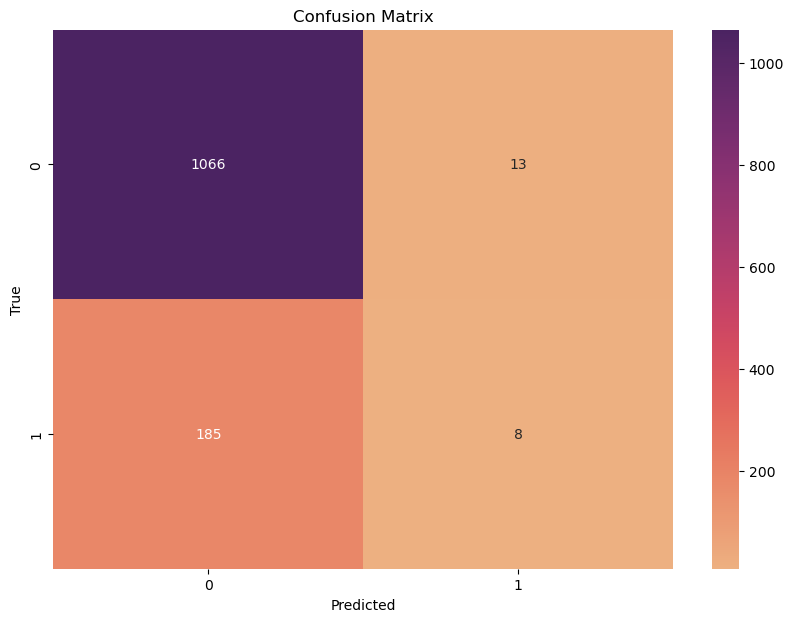

In [33]:
# Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix  
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d',cmap='flare')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [34]:
plt.savefig("confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [24]:
print(classification_report(y_test,y_pred))
print('confusion matrix')
print(cm)


              precision    recall  f1-score   support

           0       0.90      0.66      0.76      1079
           1       0.24      0.60      0.34       193

    accuracy                           0.65      1272
   macro avg       0.57      0.63      0.55      1272
weighted avg       0.80      0.65      0.70      1272

confusion matrix
[[707 372]
 [ 77 116]]


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
rfc = RandomForestClassifier()
parameters = {
    'n_estimators': [5, 10, 15, 20, 40],
    'max_features': ['log2', 'sqrt',None],
    'criterion': ['entropy', 'gini']
}

grid = GridSearchCV(rfc, parameters,cv=5)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_features': ['log2', 'sqrt', None],
                         'n_estimators': [5, 10, 15, 20, 40]})

In [26]:
print(grid.best_params_)

{'criterion': 'gini', 'max_features': 'log2', 'n_estimators': 20}


In [27]:
grid.best_score_

0.8428852890910227

Text(50.722222222222214, 0.5, 'Truth')

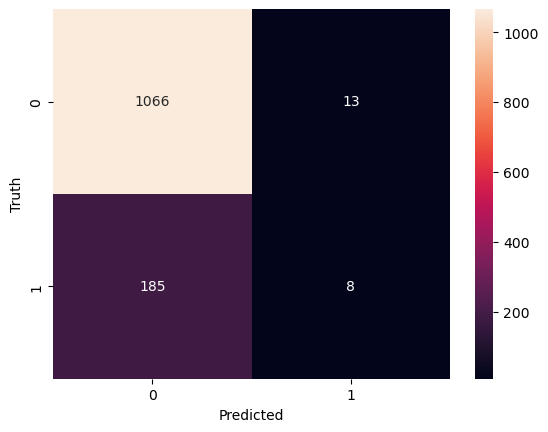

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_pred = grid.best_estimator_.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [29]:
import pickle

pickle.dump(rfc,open('logistic_regression.pkl','wb'))

model=pickle.load(open('logistic_regression.pkl','rb'))

In [30]:
import numpy as np
from flask import Flask,request,jsonify,render_template
import pickle


app=Flask(__name__)

model=pickle.load(open('logistic_regression.pkl','rb'))

@app.route('/')
def home():
    return render_template('index.html')

@app.route('/predict',methods=['POST'])
def predict():
    # for rendering results on html gui
    # Collect form data and convert to float
    age = float(request.form['Age'])
    totchol = float(request.form['Totalcholestrol'])
    sysbp = float(request.form['Sysbp'])
    diabp = float(request.form['Diabp'])
    bmi = float(request.form['BMI'])
    heartrate = float(request.form['Heartrate'])
    glucose = float(request.form['Glucose'])

    # Make prediction
    result = model.predict([age, totchol, sysbp, diabp, bmi, heartrate, glucose])
    
    # Convert result to a human-readable format
    prediction = result[0]  # Assuming it returns [0] or [1], etc.
    class_labels = {0: "Besni",1: "Kecimen"}
    class_name = class_labels.get((int(prediction)))
    result = model.predict([age, totchol, sysbp, diabp, bmi, heartrate, glucose])
    print("Raw Prediction:", result)
    # Pass prediction to the template
    return render_template('index.html', result=class_name)

@app.route('/predict_api',methods=['POST'])
def predict_api():
    # for direct calls through api request

    data= request.get_json(force=True)
    prediction = model.predict([np.array(list(data.values()))])

    output = prediction[0]
    return jsonify(output)


if __name__ == '__main__':
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1

C:\Users\asrar\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### Model Evaluation

The confusion matrix shows that the model performs well in predicting
the majority class (0) but struggles to detect positive cases (1).
This indicates a potential class imbalance in the dataset.

Although the model achieves an accuracy of approximately 84.6%, the
large number of false negatives suggests that additional techniques
such as class balancing or alternative models may improve performance.

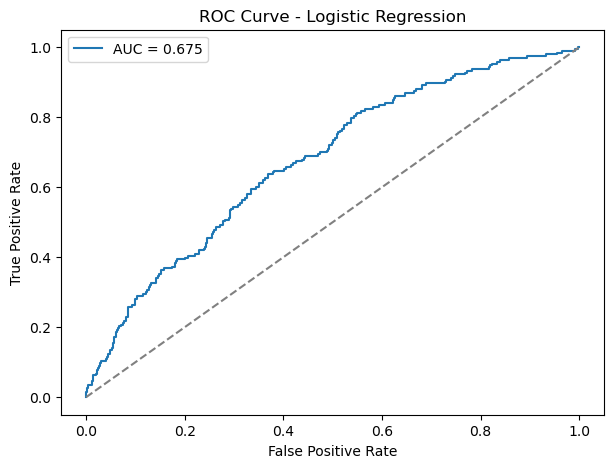

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

In [35]:
feature_importance.sort_values(by="Coefficient").plot(
    x="Feature", y="Coefficient", kind="barh"
)
plt.title("Feature Importance")
plt.savefig("feature_importance.png")

NameError: name 'feature_importance' is not defined

### Conclusion

The logistic regression model achieved an accuracy of approximately
65% on the test dataset. The confusion matrix and classification report
indicate that the model performs well for the majority class but still
struggles with precision for the minority class.

Class imbalance is likely affecting model performance. Techniques such
as resampling, SMOTE, or alternative models could further improve
prediction quality.